# 부산광역시 쓰레기 배출량 예측 pt.6

### : 종속변수 테스트

<br>

## 00. 기본 설정 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import ipywidgets as widgets
# from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

<br><br>

---
## 01. 데이터 불러오기

In [5]:
# 전처리된 폐기물 데이터
waste = pd.read_csv("../../DB/폐기물데이터_행정구역변경_2.csv", encoding="CP949")

# 병합된 X변수 데이터
iv = pd.read_csv("../../DB/x_변수병합_민주.csv", encoding="CP949")

print(f"waste shape: {waste.shape}\n")
print(f"iv shape: {iv.shape}\n")
print(f"iv columns: {iv.columns}")

waste shape: (42365, 12)

iv shape: (1145, 24)

iv columns: Index(['행정구역', '시도', '시군구', '연도', '주민등록세대수', '총인구수', '단독주택-계', '아파트', '연립주택',
       '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
       '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입', '총전출',
       '순이동'],
      dtype='object')


In [ ]:
waste shape: (42365, 12)

iv shape: (1145, 24)

iv columns: Index(['행정구역', '시도', '시군구', '연도', '주민등록세대수', '총인구수', '단독주택-계', '아파트', '연립주택',
       '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
       '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입', '총전출',
       '순이동'],
      dtype='object')


동일!

<br><br>

---
## 02. 분석 목표 정의

<br>

> **종량제 방식으로 혼합 배출되었지만, '재활용' 처리된 양 예측하기**

- 혼합배출 → 분류작업 → 재활용 처리된 자원의 양
- **이중처리로 인한 추가 비용**이 발생한 자원량을 예측하는 것  

<br>

- `5_예측모델링`에서 종속변수를 **"`종량제방식 등 혼합배출`의 `가연성+불연성` 중 `재활용` 처리된 값** 을 썼는데,
- **랜덤포레스트 + 하이퍼파라미터 튜닝**을 한 결과 `R2 = 0.5416, MSE = 0.8977`라는 결과가 나왔음
- 그래서 종속변수 값을 **`가연성+불연성+건설폐재류 중 재활용 처리된 값`** 을 설정해서 다시 모델링 및 튜닝을 해보고자 함

<br>

### 추가
- 연도 변수 (one-hot encoding)

<br><br>

---
## 03. 폐기물 데이터 전처리

<br>

### 03-1. 종속변수 y값 정의하기
> 혼합배출된 종량제 폐기물 중에서 실제로 재활용 처리된 양의 총합을 종속변수로 설정 (가연성+불연성+건설폐재류 모두)
```
혼합배출_후_재활용량 = 
    폐기물_종류 == '종량제방식 등 혼합배출' AND
    '재활용' 컬럼의 값 합계
```

<br>

### 03-2. y값 계산
- 우선 폐기물_종류 == 종량제방식 등 혼합배출인 데이터 중 `재활용` 처리된 값의 합을 구하고
- 그 합계가 0 이상인 폐기물_종류2 목록을 출력해보기로

In [6]:
# 종량제방식 등 혼합배출 데이터프레임 필터링
filtered = waste[waste['폐기물_종류'] == '종량제방식 등 혼합배출'].reset_index(drop=True)
filtered.shape

(17175, 12)

In [7]:
# 폐기물_종류1 별 재활용량 합계
recycle_by_type = (
    filtered
    .groupby(['폐기물_종류1'])['재활용']
    .sum()
    .reset_index()
)

# 재활용량이 0 이상인 폐기물_종류2만 필터링
recycle_by_type = recycle_by_type[recycle_by_type['재활용'] > 0]
recycle_by_type

,폐기물_종류1,재활용
0,가연성,4835911.9
1,건설폐재류,360422.5
2,기타(배출불명등),36782.5
3,불연성,424053.0


위 표는 `종량제 방식`으로 혼합 배출된 폐기물 중에서 `재활용` 처리된 폐기물을 `폐기물_종류1`별로 집계한 결과임.

- 이 값은 **추가적인 인력/비용을 들여 재활용된 양** 의미
- 정책적 관점에서 **이중 처리된 재활용 자원**으로 볼 수 있으며, 예측의 타겟(Y값)이 될 것임

<br><br>


In [8]:
# 폐기물_종류1과 관계 없이 종량제방식 중 '재활용'된 값만 계산한 코드
target = (
    filtered
    .groupby(['행정구역', '연도'])['재활용']
    .sum()
    .reset_index()
    .rename(columns={'재활용': '혼합배출_후_재활용량'})
)
print(f"target_y shape (0-value 필터링 전): {target.shape}\n")
target.head()

target_y shape (0-value 필터링 전): (1145, 3)



,행정구역,연도,혼합배출_후_재활용량
0,강원_강릉시,2019,0.0
1,강원_강릉시,2020,0.0
2,강원_강릉시,2021,0.0
3,강원_강릉시,2022,0.0
4,강원_강릉시,2023,0.0


### 추가)
- 종속변수에 `건설폐재류`를 추가했을 경우와 추가하지 않았을 경우
    - 추가하지 않았을 경우, 같은 조건에서 선형회귀의 설명력이 약 `0.02` 정도 상승
    - 추가했을 경우, 같은 조건에서 랜덤포레스트의 설명력이 약 `0.09` 정도 감소

> **여기까지의 결과만으로 보자면, `건설폐재류`를 종속변수에 포함하는 것이 설명력 증가에 유리함!** (`기타`도 작은 값이니 그냥 추가)

In [9]:
print(f"y값(`혼합배출_후_재활용량`)이 0인 지역의 수: {len(target[target['혼합배출_후_재활용량']==0]['행정구역'].unique())}")
print(f"y값(`혼합배출_후_재활용량`)이 0인 행의 수: {target[target['혼합배출_후_재활용량'] == 0].shape[0]}")
target[target['혼합배출_후_재활용량']==0]['행정구역'].unique()

y값(`혼합배출_후_재활용량`)이 0인 지역의 수: 159
y값(`혼합배출_후_재활용량`)이 0인 행의 수: 555


array(['강원_강릉시', '강원_고성군', '강원_속초시', '강원_양양군', '강원_영월군', '강원_인제군',
       '강원_정선군', '강원_철원군', '강원_춘천시', '강원_태백시', '강원_평창군', '강원_화천군',
       '강원_횡성군', '경기_가평군', '경기_고양시', '경기_과천시', '경기_광명시', '경기_광주시',
       '경기_군포시', '경기_동두천시', '경기_성남시', '경기_수원시', '경기_시흥시', '경기_안산시',
       '경기_안성시', '경기_안양시', '경기_양평군', '경기_여주시', '경기_연천군', '경기_오산시',
       '경기_용인시', '경기_의왕시', '경기_의정부시', '경기_포천시', '경기_하남시', '경남_거제시',
       '경남_거창군', '경남_고성군', '경남_남해군', '경남_밀양시', '경남_사천시', '경남_산청군',
       '경남_양산시', '경남_진주시', '경남_창녕군', '경남_창원시', '경남_통영시', '경남_함안군',
       '경남_합천군', '경북_경주시', '경북_고령군', '경북_구미시', '경북_김천시', '경북_문경시',
       '경북_봉화군', '경북_상주시', '경북_성주군', '경북_안동시', '경북_영양군', '경북_영주시',
       '경북_예천군', '경북_울릉군', '경북_울진군', '경북_의성군', '경북_청도군', '경북_청송군',
       '경북_칠곡군', '대구_군위군', '서울_강남구', '서울_강동구', '서울_강서구', '서울_관악구',
       '서울_광진구', '서울_구로구', '서울_금천구', '서울_도봉구', '서울_동대문구', '서울_동작구',
       '서울_마포구', '서울_서대문구', '서울_서초구', '서울_성동구', '서울_성북구', '서울_송파구',
       '서울_영등포구', '서울_은평구', '서울_종로구', '서울_중구', '서울_중랑구', '

<br>

### 03-3. `혼합배출_후_재활용량`이 0인 행을 삭제 하기 전 iv 데이터프레임과 병합

In [10]:
print(target.shape)
print(iv.shape)

(1145, 3)
(1145, 24)


In [11]:
# target: 종속변수, iv: 독립변수
merged = pd.merge(target, iv, on=['행정구역', '연도'], how='left')
print(merged.shape)
merged.head(3)

(1145, 25)


,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,다세대주택비율,비주거용주택비율,1인가구,2인가구,3인가구,4인가구,5인이상가구,총전입,총전출,순이동
0,강원_강릉시,2019,0.0,강원,강릉시,99086,213442,29481,50175,2919,...,0.0171,0.0202,32119,28629,16547,11083,3715.0,31980,30787,1193
1,강원_강릉시,2020,0.0,강원,강릉시,101424,213321,29549,51631,3161,...,0.0167,0.0202,37635,29649,16499,10810,3439.0,31595,30983,612
2,강원_강릉시,2021,0.0,강원,강릉시,102879,212965,29625,53159,3212,...,0.0164,0.0201,38581,30768,16191,10369,3196.0,31820,30668,1152


In [12]:
merged.columns

Index(['행정구역', '연도', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택-계',
       '아파트', '연립주택', '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율',
       '다세대주택비율', '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입',
       '총전출', '순이동'],
      dtype='object')

<br><br>

---

### 03-4. `혼합배출 후 재활용량`의 결측치 처리
- 전체 데이터를 기준으로, 159개의 지역에는 특정 연도에 `혼합배출_후_재활용량`이 **전혀 없거나 0**인 경우가 있음
- 아래와 같은 경우일 수 있다:
    - 실제로 `종량제방식`에서 재활용 처리가 이루어지지 않음
    - 관련 데이터가 측정되지 않음
    - 혼합배출 쓰레기를 따로 재활용 처리하지 않고 소각/매립하는 시스템을 가진 지역
    
<br>

> 모델링 결과가 안 좋게 나올 수 있고, **"이중 처리로 인한 추가 비용이 발생하지 않은"** 케이스이므로 우선 `Y=0`인 행 제거

In [13]:
# merged에 포함된 행정구역 수 확인
print(f"merged 내 고유 행정구역 수: {merged['행정구역'].nunique()}")

# 혼합배출_후_재활용량 == 0인 행정구역만 따로
zero_recycle_regions = target[target['혼합배출_후_재활용량'] == 0]['행정구역'].unique()

# merged에서 해당 지역만 필터링
merged_zero_rows = merged[
    (merged['행정구역'].isin(zero_recycle_regions)) &
    (merged['혼합배출_후_재활용량'] == 0)
]
print(f"merged 내 y=0인 행의 수: {merged_zero_rows.shape[0]}")

merged 내 고유 행정구역 수: 229
merged 내 y=0인 행의 수: 555


In [14]:
merged = merged[merged['혼합배출_후_재활용량'] > 0].reset_index(drop=True)
print(f"혼합배출 후 재활용량을 제거한 후의 merged 데이터프레임: {merged.shape}")
merged.head(3)

# 가연성+불연성만 따졌을 때보다 18개의 행이 많아짐 (1145 - 555)

혼합배출 후 재활용량을 제거한 후의 merged 데이터프레임: (590, 25)


,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,다세대주택비율,비주거용주택비율,1인가구,2인가구,3인가구,4인가구,5인이상가구,총전입,총전출,순이동
0,강원_고성군,2022,2863.8,강원,고성군,15291,27274,9011,3478,153,...,0.0115,0.0281,4755,4494,1774,920,366.0,3269,2968,301
1,강원_고성군,2023,2467.3,강원,고성군,15431,27305,9021,3495,153,...,0.0114,0.0280,5348,4552,1729,914,323.0,3262,2989,273
2,강원_동해시,2019,4818.0,강원,동해시,41141,90522,10461,24961,1657,...,0.0296,0.0173,10543,12086,7172,4833,1580.0,10516,11039,-523


<br><br>



### 03-5. `target` 데이터의 기초 통계 확인

In [15]:
merged['혼합배출_후_재활용량'].describe()

count      590.000000
mean      9588.423559
std      12147.345864
min          9.200000
25%       1997.900000
50%       5746.450000
75%      12456.925000
max      99404.800000
Name: 혼합배출_후_재활용량, dtype: float64

> 평균(9588.423559)보다 표준편차(12147.345864)가 커서 **우측으로 긴 꼬리를 가진 비대칭 분포**일 가능성이 큼

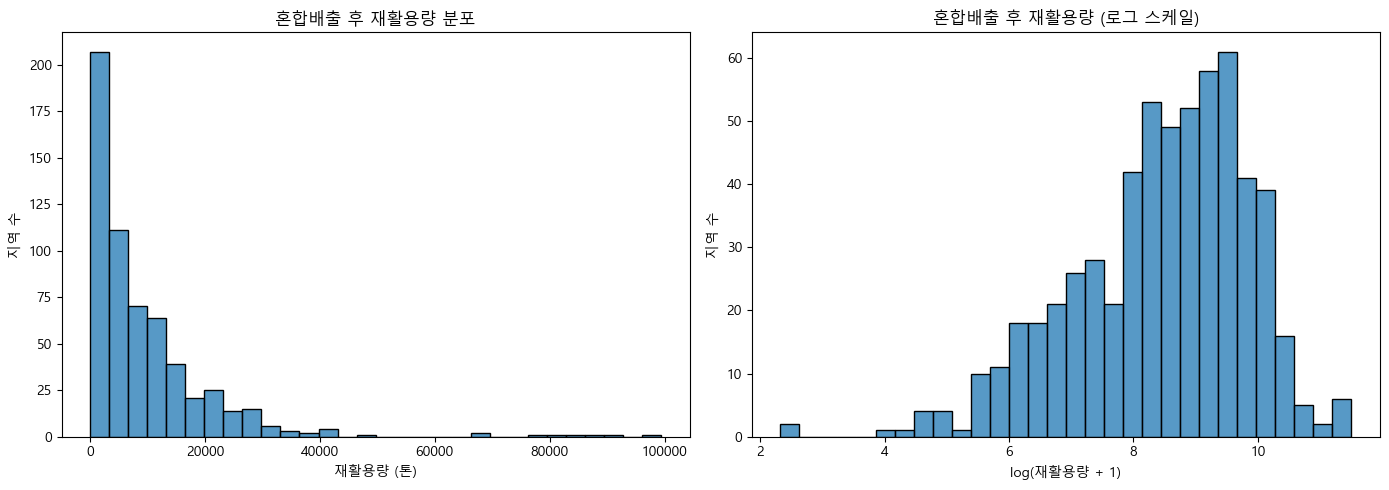

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원래 값 분포
sns.histplot(
    data=merged,
    x='혼합배출_후_재활용량',
    bins=30,
    edgecolor='black',
    ax=axes[0],
)
axes[0].set_title('혼합배출 후 재활용량 분포')
axes[0].set_xlabel('재활용량 (톤)')
axes[0].set_ylabel('지역 수')

# 로그 변환 분포
sns.histplot(
    x=np.log1p(merged['혼합배출_후_재활용량']),
    bins=30,
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('혼합배출 후 재활용량 (로그 스케일)')
axes[1].set_xlabel('log(재활용량 + 1)')
axes[1].set_ylabel('지역 수')

plt.tight_layout()

- 모델에는 log_혼합배출_후_재활용량을 사용하고
- 예측 후에는 `np.expm1()`으로 **원래 스케일(톤 단위)** 로 다시 바꾸기

In [17]:
# Y값을 로그 변환한 컬럼 추가
merged['log_혼합배출_후_재활용량'] = np.log1p(merged['혼합배출_후_재활용량'])
merged[['혼합배출_후_재활용량', 'log_혼합배출_후_재활용량']].describe()

,혼합배출_후_재활용량,log_혼합배출_후_재활용량
count,590.000000,590.000000
mean,9588.423559,8.435127
std,12147.345864,1.406751
min,9.200000,2.322388
25%,1997.900000,7.600347
50%,5746.450000,8.656509
75%,12456.925000,9.430111
max,99404.800000,11.506966


### 이상치 처리 할말?
- 로그 변환한 걸 DV로 사용하기로 했으니 이상치 처리는 안 하는 게 맞을 거 같다!
- 트리 기반 모델에서는 **이상치가 존재해도 전체 모델 학습에 거의 영향이 없으니** 이상치 처리를 따로 하지 않아도 됨
- 오히려 이상치를 유지함으로써 **높은 배출량을 가진 지역도 함께 학습**됨

Text(0.5, 1.0, '로그 스케일 boxplot')

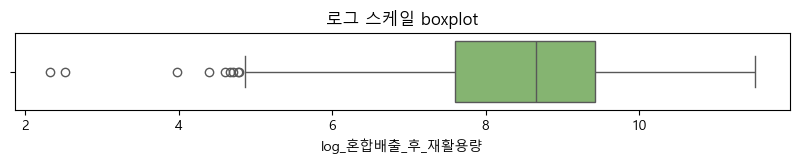

In [18]:
# 그래도 boxplot은 그려보기
plt.figure(figsize=(10, 1))
sns.boxplot(x=merged['log_혼합배출_후_재활용량'], palette = 'summer')
plt.title('로그 스케일 boxplot')

<br><br>

---

### 03-6. 추가 시각화

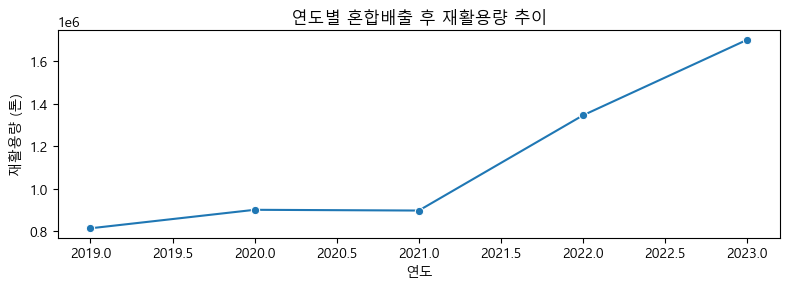

In [19]:
# 연도별 합계
yearly = merged.groupby('연도')['혼합배출_후_재활용량'].sum().reset_index()

plt.figure(figsize=(8, 3))
sns.lineplot(data=yearly, x='연도', y='혼합배출_후_재활용량', marker='o')
plt.title('연도별 혼합배출 후 재활용량 추이')
plt.xlabel('연도')
plt.ylabel('재활용량 (톤)')
plt.tight_layout()

In [20]:
yearly

,연도,혼합배출_후_재활용량
0,2019,812891.5
1,2020,900093.2
2,2021,896600.7
3,2022,1345621.0
4,2023,1701963.5


### 연도별 혼합배출 재활용량 증가 추세 (`혼합배출_후_재활용량` > 0인 지역만)
- 2019년 `812891.5` → 2023년 `1701963.5` (두 배 이상 증가)
- 해석
    - 이는 사람들의 **분리배출 실패가 늘었거나**
    - **분류 시스템이 개선되어 더 많이 선별/재활용**되었거나
    - **혼합배출량 자체가 증가**했을 가능성이 있음
> 이 추세는 정책적으로 **이중 처리**로 인한 비용이 급증하고 있을 수 있음을 의미함.
> → 혼합배출량이 아니라 **“혼합된 것 중 재활용된 양”** 이니까 **처리 시스템 부담 증가**로 해석할 수 있을 듯

<br>

### "혼합배출이 많다 != 시민 참여가 낮다" → 혼합배출은 많지만, 잘 선별해서 재활용하는 시스템이 있기 때문일 수도

> 혼합배출이 많고 재활용량이 많은 지역은 “후처리 부담 지역”, 반대로 혼합배출이 적고 재활용도 적은 지역은 **“무관심/측정 누락 가능성”**으로 분류 가능함

<br>

### 연도 feature를 모델에 추가하면?
- 종속 변수가 연도에 따라 뚜렷한 경향성을 보이는 상황이니 연도 정보를 모델에 독립 변수로 넣어주는 게 좋을 것 같다는 판단

<br><br>

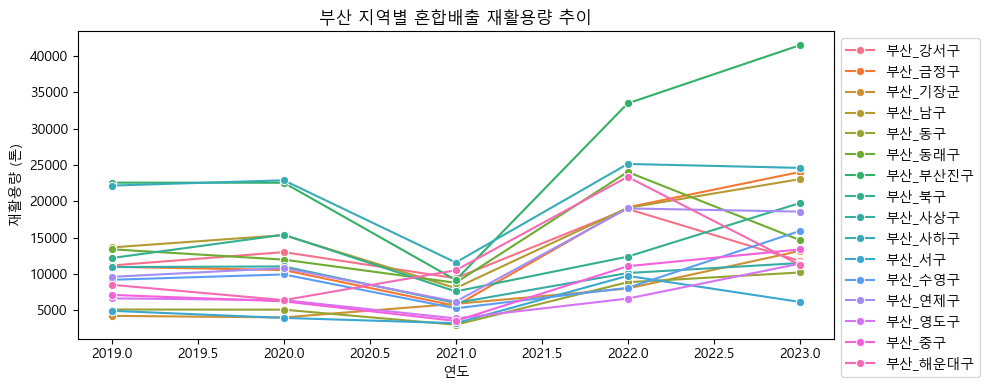

In [21]:
# 부산광역시 관련 지역만 보기
busan = merged[merged['행정구역'].str.startswith('부산')]

plt.figure(figsize=(10, 4))
sns.lineplot(data=busan, x='연도', y='혼합배출_후_재활용량', hue='행정구역', marker='o')
plt.title('부산 지역별 혼합배출 재활용량 추이')
plt.xlabel('연도')
plt.ylabel('재활용량 (톤)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

<br><br>

---
## 04. 독립변수 전처리
- 가구원수 별 가구 수, 주택 종류별 주택 수 컬럼은 비율을 사용
- 상관관계가 높은 변수는 하나만 선택하기

<br>

### 04-1. 비율 변수로 변경 (`가구원수 별 가구 수`, `주택 종류별 주택 수`) & col 삭제

In [22]:
merged_processed = merged.copy()

# 가구 비율 컬럼 추가
for col in ['1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구']:
    merged_processed[f'{col}_비율'] = merged_processed[col] / (merged_processed[['1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구']].sum(axis=1))

merged_processed.head(1)

,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,5인이상가구,총전입,총전출,순이동,log_혼합배출_후_재활용량,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율
0,강원_고성군,2022,2863.8,강원,고성군,15291,27274,9011,3478,153,...,366.0,3269,2968,301,7.960254,0.386303,0.365099,0.144122,0.074742,0.029734


In [23]:
# 사용하지 않을 칼럼 삭제
cols_to_drop = [
    '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구',
    '단독주택-계', '아파트', '연립주택', '다세대주택', '비주거용 건물 내 주택'
]
merged_processed = merged_processed.drop(columns=cols_to_drop)
print(merged_processed.shape)
print(merged_processed.columns)

(590, 21)
Index(['행정구역', '연도', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율',
       '5인이상가구_비율'],
      dtype='object')




<br>

### 04-2. 연도 변수 원-핫 인코딩

In [24]:
from pandas.api.types import is_bool_dtype

In [25]:
merged_encoded = pd.get_dummies(merged_processed, columns=['연도'], prefix='연도')
print(f"one-hot encoding 후 merged_encoded shape: {merged_encoded.shape}")
print(f"merged_encoded cols:\n{merged_encoded.columns.tolist()}\n")

one-hot encoding 후 merged_encoded shape: (590, 25)
merged_encoded cols:
['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동', 'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']



In [26]:
for col in merged_encoded.columns:
    if col.startswith('연도_') and is_bool_dtype(merged_encoded[col]):
        merged_encoded[col] = merged_encoded[col].astype(int)

merged_encoded.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0


In [27]:
# 모델학습에 사용할 최종 데이터프레임 저장
merged_encoded.to_csv("../../DB/최종_모델학습용.csv", encoding='cp949', index=False)